#Phase 5 — Model Evaluation

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


Load Final Model and Test Data

In [2]:
# Load final Gradient Boosting model
model = joblib.load("churn_model.pkl")

# Load processed test data
X_test_processed = np.load("X_test_processed.npy")
y_test = np.load("y_test.npy")

print("Model loaded successfully!")
print("Test data:", X_test_processed.shape)
print("Test labels:", y_test.shape)

Model loaded successfully!
Test data: (1409, 45)
Test labels: (1409,)


Generate Predictions

In [3]:
y_pred = model.predict(X_test_processed)

y_prob = model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


Final Performance Metrics

In [4]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Final Model Performance")
print("=======================")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Final Model Performance
Accuracy : 0.8027
Precision: 0.6655
Recall   : 0.516
F1 Score : 0.5813
ROC-AUC  : 0.8433


Classification Report

In [5]:
print("Classification Report")
print("=====================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

Classification Report
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



Confusion Matrix

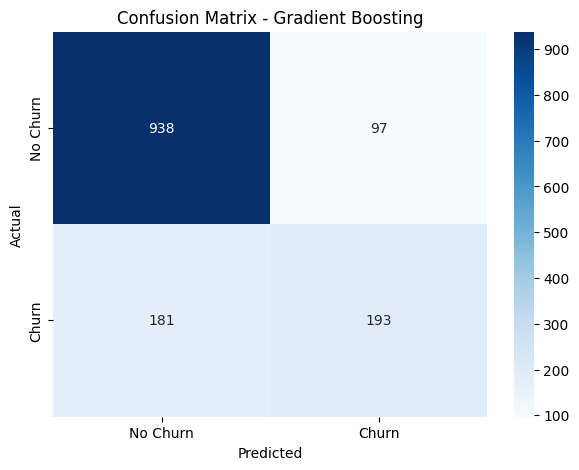

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC Curve

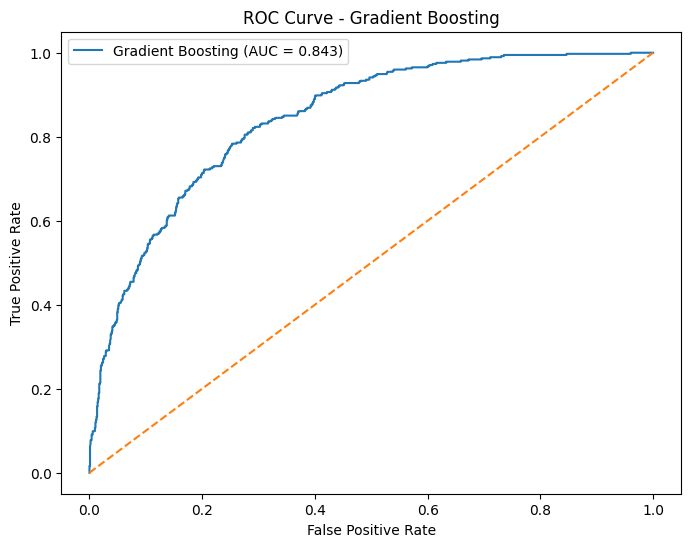

In [7]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()

plt.show()

Final Evaluation Table

In [8]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(final_results.round(4))

,Metric,Score
0,Accuracy,0.8027
1,Precision,0.6655
2,Recall,0.5160
3,F1 Score,0.5813
4,ROC-AUC,0.8433


In [12]:
# Display confusion matrix values

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Confusion Matrix:
[[938  97]
 [181 193]]

True Negatives : 938
False Positives: 97
False Negatives: 181
True Positives : 193


In [11]:
# Calculate churn detection rate

churn_detection_rate = tp / (tp + fn) * 100

print(
    "Actual churners correctly identified:",
    round(churn_detection_rate, 2),
    "%"
)

Actual churners correctly identified: 51.6 %


Get Feature Names

In [13]:
preprocessor = joblib.load("preprocessor.pkl")

feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of feature names: 45

First 20 features:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__Contract_Month-to-month'
 'cat__Contract_One year' 'cat__Contract_Two year'
 'cat__PaperlessBilling_No' 'cat__PaperlessBilling_Yes'
 'cat__PaymentMethod_Bank transfer (automatic)'
 'cat__PaymentMethod_Credit card (automatic)'
 'cat__PaymentMethod_Electronic check' 'cat__PaymentMethod_Mailed check'
 'cat__PhoneService_No']


eature Importance

In [14]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance.head(15).round(4)
)

,Feature,Importance
10,cat__Contract_Month-to-month,0.3797
1,num__tenure,0.1419
25,cat__InternetService_Fiber optic,0.0860
3,num__TotalCharges,0.0858
2,num__MonthlyCharges,0.0802
27,cat__OnlineSecurity_No,0.0679
17,cat__PaymentMethod_Electronic check,0.0442
36,cat__TechSupport_No,0.0375
21,cat__MultipleLines_No,0.0119
13,cat__PaperlessBilling_No,0.0111


Visualize Top Features

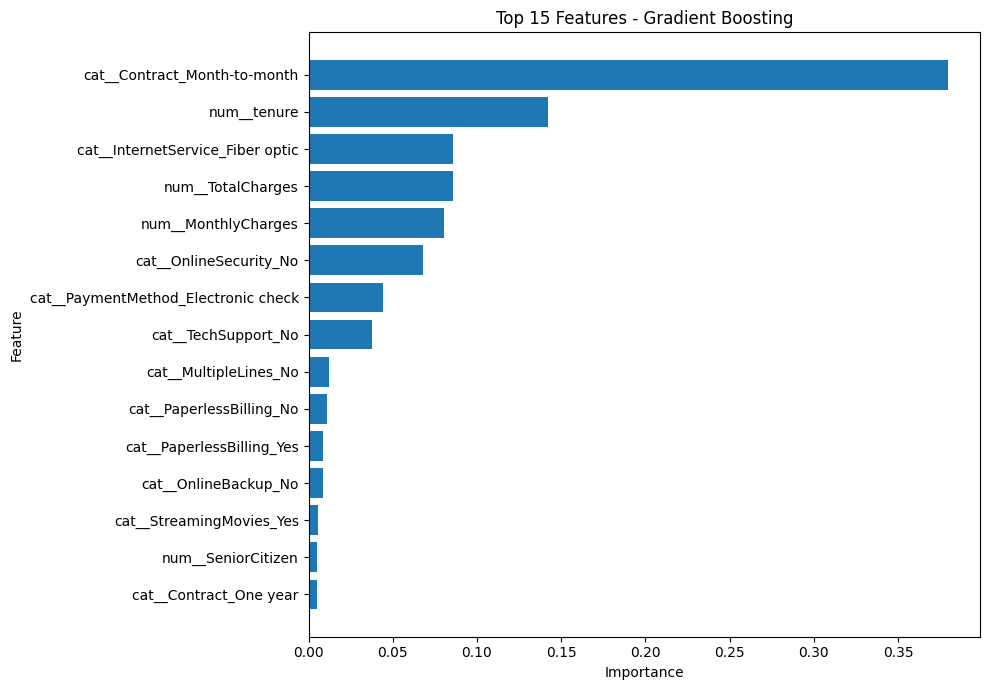

In [15]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Gradient Boosting")

plt.tight_layout()
plt.show()

# Feature Importance Analysis

Feature importance was analyzed using the trained Gradient Boosting model.

The most influential feature was `Contract_Month-to-month`, followed by `tenure`, `InternetService_Fiber optic`, `TotalCharges`, and `MonthlyCharges`.

Other important features included `OnlineSecurity_No`, `PaymentMethod_Electronic check`, and `TechSupport_No`.

The results indicate that contract type, customer tenure, internet service, charges, payment method, and technical support are important predictive factors in customer churn.

The feature importance results also support the findings from the EDA, particularly the importance of month-to-month contracts and shorter customer tenure.